In [35]:
# %% Import libraries
from scipy.io import savemat
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mesa.features import stft, stft_labels
from mesa.visualization import plot_signal, dual_plot, spectrogram
import librosa
from airPLS import airPLS


In [36]:
# % Read data
F_data = pd.read_csv("../../data/GC-FID/Y_data.csv", header=None)
F_data_matrix = F_data.to_numpy()

idx = np.where(np.sum(F_data_matrix, axis=1)==0)

df = pd.read_csv("../../data/GC-FID/X_data.csv", header=None)
X = df.to_numpy()
X = np.delete(X, idx, axis=1).T
X.shape

(96, 45001)

In [37]:
# %% Baseline reduction using airPLS
print("Removing baseline...")
for sample_id in range(X.shape[0]):
    correction = airPLS(X[sample_id])
    X[sample_id] -= correction

Removing baseline...


In [38]:
# STFT params
sr = 200
window_length = 45001
n_fft = window_length
hop = window_length
window = "boxcar"
n_bins = window_length
center = True

D = stft(X,window_length,hop, window=window, center=center, n_fft = n_fft)
Sxx = np.abs(D)**2
Sxx = librosa.amplitude_to_db(np.abs(D))

times, freqs = stft_labels(D, sr, hop, n_fft = n_fft)

print(f"Sxx.shape: {Sxx.shape}")

Sxx.shape: (96, 22501, 1)


In [39]:
### Eliminate filtered frequencies
# A high-pass filter with 0.5 Hz cut-off frequency, low-pass filter with 45 Hz cut-off frequency and a power line notch filter (50 Hz) were used
mask = np.ones(len(freqs), dtype=bool)

mask[freqs > 15.0] = False
mask[freqs <  0.0] = False
# id_50Hz = np.argmin(np.abs(freqs - 50.0))
# mask[id_50Hz] = False


freqs = freqs[mask]
Sxx = Sxx[:, mask, :]
n_frequencies = len(freqs)
print(f"Nº of frequencies after  masking the filter: {n_frequencies}")

Nº of frequencies after  masking the filter: 3376


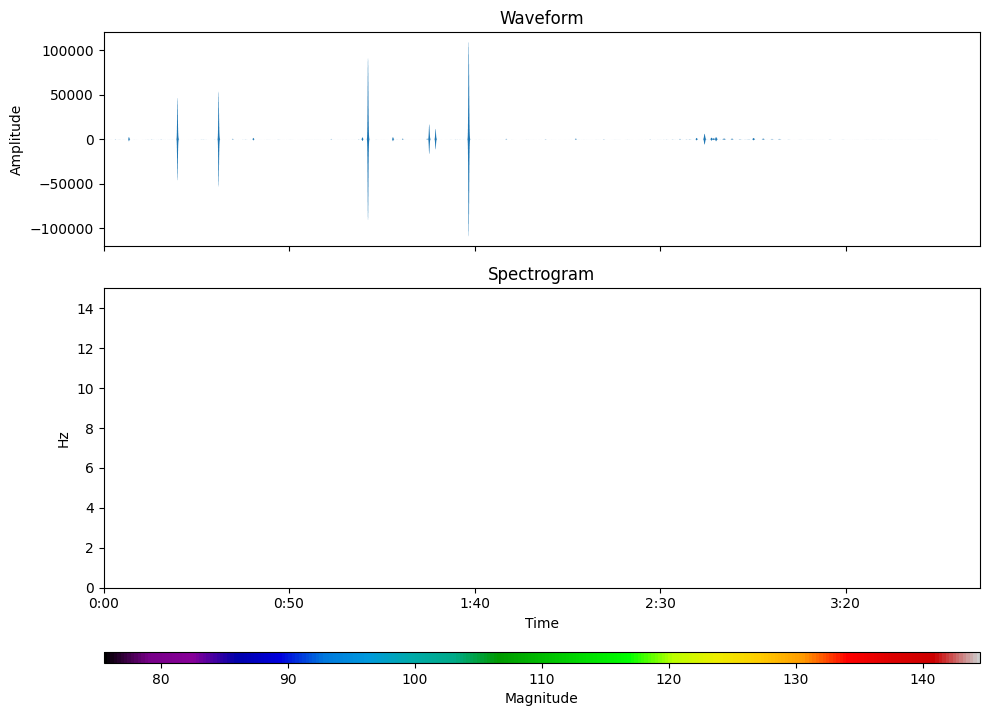

In [40]:
id = 5
dual_plot(X[id],Sxx[id], sr, window_length, hop, n_fft, center,
          cmap="nipy_spectral", y_coords=freqs);

In [41]:
# %% Unfolding
from mesa.fusion import unfold_2D
subjects = np.arange(96)+1
labels = [subjects, freqs, times]
label_names = ["subjects", "freq", "time"]
X_unfold, labels_unfold, label_names = unfold_2D(Sxx,rows=[0], cols=[1,2],
                                                 labels=labels, label_names=label_names)

In [42]:
X.shape, Sxx.shape, X_unfold.shape, label_names

((96, 45001), (96, 3376, 1), (96, 3376), [['subjects'], ['freq', 'time']])

In [43]:
X_peak = pd.read_csv("../../data/GC-FID/X_peak.csv", header=None)
F_peak = pd.read_csv("../../data/GC-FID/Y_peak.csv", header=None)
F_data = pd.read_csv("../../data/GC-FID/Y_data.csv", header=None)
F_data = np.delete(F_data.to_numpy(), idx, axis = 0)

In [44]:
from scipy.io import savemat

savemat(
    "GC-FIG.mat", {"data": X_unfold,
                    "label_names": np.array(label_names, dtype=object),
                    "obs_l": np.array(labels_unfold[0],  dtype=object),
                    "var_l": np.array(labels_unfold[1],  dtype=object),
                    "F_data": F_data}
)